Project for the course "Big Data and Text Mining" of Giorgio Scavello (giorgio.scavello@studio.unibo.it), #0001169261

# RAG-based ARASAAC Pictogram Retrieval for AAC Comunication

This project consists of an end-to-end pipeline with the goal of retrieving pictograms from the ARASAAC database based on a input of text made by the user. The pipeline is composed of three main steps:
Insertion of a query from the user → LLM simplification of the query (noise removal) → pictogram retrieval via text embedder using the simplified query → CE reranking of retrieved candidates using the simplified query. <br>
In this project also a comparison on the latency and performance of a local LLM via Ollama and an LLM run in the browser via WebLLM is made, to see if this pipeline can be run easily on a browser page without the need of a local installation of an LLM. <br>

Let's import the required libraries for this project. Also the utilities created will be imported from the utils.py file.

In [6]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Install all required packages (run once in Colab)
# torch/torchvision are NOT listed here — use Colab's preinstalled version
# so that flash-attn prebuilt wheels are compatible
# numpy/scipy/pandas are also NOT pinned — Colab preinstalls its own versions of
# these, already imported before this cell runs; force-pinning them causes a
# numpy ABI mismatch (ImportError: cannot import name '_center' from
# 'numpy._core.umath') since the already-loaded compiled extension doesn't match
# the newly installed pure-Python files until a runtime restart.
# Versions pinned to the ones used in development (conda env 'nlp')
!pip install -q \
    "transformers==5.12.1" \
    "qwen-vl-utils==0.0.14" \
    "matplotlib==3.10.6" \
    "Pillow==11.3.0" \
    "huggingface-hub==1.16.4" \
    "datasets==4.4.2" \
    "sentence-transformers==5.6.0" \
    "accelerate==1.12.0" \
    "langchain-core==1.4.7" \
    "langchain-ollama==1.0.1" \
    "langchain-community==0.4.1" \
    "langchain-huggingface==1.2.2" \
    "pymilvus==2.4.9" \
    "milvus-lite==2.4.9" \
    "tqdm==4.67.1" \
    "ollama==0.6.1" \
    "flask==3.1.0" \
    "flask-cors==6.0.2" \
    "fastapi==0.135.1" \
    "uvicorn[standard]==0.41.0" \
    "pydantic==2.12.5" \
    "gdown==6.0.0" \
    "marshmallow==3.20.0" \
    "torchao==0.17.0" \
    "pyngrok==8.1.2"

In [8]:
import os
if not os.path.exists('./BDATM-project'):
  !git clone https://github.com/Shardyne/BDATM-project.git
else:
  print('already cloned')

Cloning into 'BDATM-project'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (37/37), done.
^Cceiving objects:  11% (10/86), 41.68 MiB | 13.86 MiB/s


In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import ast
import io
import math
import pickle
import random
import re
import socket
import threading
import time
import warnings
from collections import defaultdict
import json
import sys
import gdown
import zipfile

warnings.filterwarnings('ignore')
os.chdir('/content/BDATM-project')

# ── Data science ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# ── Deep learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn.functional as F

# ── Image processing ──────────────────────────────────────────────────────────
from PIL import Image

# ── Progress ──────────────────────────────────────────────────────────────────
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook

# ── HuggingFace ───────────────────────────────────────────────────────────────
from huggingface_hub import login, hf_hub_download, list_repo_files
from datasets import load_dataset
from transformers import AutoModel
from sentence_transformers import CrossEncoder
from google.colab import userdata


# ── LangChain ─────────────────────────────────────────────────────────────────
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_ollama import OllamaEmbeddings
from langchain_community.embeddings import OllamaEmbeddings as OllamaEmbeddingsCommunity
from langchain_community.embeddings import HuggingFaceEmbeddings

# ── Vector DB ─────────────────────────────────────────────────────────────────
from pymilvus import MilvusClient

# ── Web / API ─────────────────────────────────────────────────────────────────
import ollama
import uvicorn
from flask import Flask, request, jsonify
from flask_cors import CORS
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from fastapi.staticfiles import StaticFiles
from pydantic import BaseModel
from IPython.display import display, HTML
from pyngrok import ngrok
import shutil


# ── Utils ─────────────────────────────────────────────────────────────────
import importlib
import BDATM.utils
importlib.reload(BDATM.utils)
from BDATM.utils import *

# One-time: get a free account at ngrok.com, copy your authtoken
ngrok.set_auth_token(userdata.get("GROK_TOKEN"))

Install ollama and pull the required LLMs

In [ ]:
# install ollama
!sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

In [15]:
import subprocess, time

# Start server
subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(3)

## 2. Load and present the datasets

In this project two datasets have been used: one containing a set of sentences and their corresponding concepts has been used and the other containing the ARASAAC pictograms. Let's load first the one about senteces and later the one about pictograms.

### 2.1 Sentences and concepts dataset

In [17]:
login(token=userdata.get('HF_TOKEN'))

# Download the sentences split
path = hf_hub_download(
    repo_id="disi-unibo-nlp-students/aac_database",
    filename="data/sentences/train-00000-of-00001.parquet",
    repo_type="dataset"
)

# download the parquet file and show the first 10 rows
df_sentences = pd.read_parquet(path)
df_sentences.head(10)

,sentence,concepts
0,The blue train is going fast.,[{'candidates': [{'description': 'Passenger tr...
1,I see the big yellow bus.,"[{'candidates': [{'description': ""The word is ..."
2,The music is too loud in here.,"[{'candidates': [{'description': ""The word is ..."
3,Look at the bubbles popping.,"[{'candidates': [{'description': ""The word is ..."
4,My shirt feels scratchy on my neck.,[{'candidates': [{'description': 'person weari...
5,The fan is spinning round and round.,[{'candidates': [{'description': 'Person using...
6,I like the crunchy crackers.,"[{'candidates': [{'description': ""The word is ..."
7,Teacher Sarah has the red blocks.,[{'candidates': [{'description': 'Teacher inst...
8,The sandbox is cold today.,"[{'candidates': [{'description': ""sand box wit..."
9,I see a bird outside the window.,"[{'candidates': [{'description': ""The word is ..."


The dataset has only 2 columns: one containing the sentences and the other with the concepts associated to the corresponding sentence. The ``concepts`` column however should furtherly seen. Here the first example is presented.

In [18]:
# print the first sentence and the corresponding concepts
print(df_sentences['sentence'][0])
df_sentences['concepts'][0]

The blue train is going fast.


array([{'candidates': array([{'description': 'Passenger train composed of a locomotive and a carriage for transporting travelers on rails', 'id': '2603', 'keywords': 'train, passenger train'},
              {'description': 'A steam-powered train with a passenger carriage, designed for public transportation.', 'id': '29010', 'keywords': ''},
              {'description': 'Passenger train composed of multiple connected carriages for transporting travelers on tracks', 'id': '7282', 'keywords': 'train, passenger train'},
              {'description': 'Train movement along rail track with marked paths indicating direction or route selection.', 'id': '10187', 'keywords': 'travel, cover, train, rail'},
              {'description': 'Railway conductor standing beside high-speed train on tracks, representing transportation service role', 'id': '36763', 'keywords': 'engine driver, engineer, locomotive engineer'},
              {'description': 'railway station where trains arrive and depart for p

From here it is possible to see that for each phrase there is a group of concepts associated. For each concept there is a pictogram which by the annotators was considered as the gold example for that concept and the a group of possible candidates as some pictograms could be still valid for that concept. The last entry is the corresponding text in the initial sentence. It is also possible to see that some descriptions cannot be used as they do not mean anything. Let's see if any entry of the dataset are not available


In [19]:
# count how many non unique pictograms are not affected
total_descs = 0
bad_descs = 0
bad_pids = set()
total_pids = set()

for concepts in df_sentences['concepts']:
    if concepts is None or len(concepts) == 0:
        continue
    for entry in concepts:
        if not isinstance(entry, dict):
            continue

        # selected pictogram
        pic = entry.get('pictogram') or {}
        pid = pic.get('id')
        desc = pic.get('description', '')
        if pid is not None:
            total_pids.add(pid)
            total_descs += 1
            if is_unusable_description(desc):
                bad_descs += 1
                bad_pids.add(pid)

        # candidates
        candidates = entry.get('candidates')
        if candidates is None or len(candidates) == 0:
            continue
        for cand in candidates:
            if not isinstance(cand, dict):
                continue
            pid = cand.get('id')
            desc = cand.get('description', '')
            if pid is not None:
                total_pids.add(pid)
                total_descs += 1
                if is_unusable_description(desc):
                    bad_descs += 1
                    bad_pids.add(pid)

print(f"Total descriptions (selected + candidates): {total_descs}")
print(f"Unintelligible descriptions:                {bad_descs} ({bad_descs/total_descs*100:.2f}%)")
print(f"Unique pictograms affected:                 {len(bad_pids)} / {len(total_pids)}")


Total descriptions (selected + candidates): 101970
Unintelligible descriptions:                8559 (8.39%)
Unique pictograms affected:                 4 / 2854


The problem of having unintellegible descriptions for pictograms is not influential as it affect only 5 pictograms out of the 2854 found. <br>
As the sentences in the dataset, which in our pipeline should be used as queries for the pictogram retrieval, are not a good example of real queries, but rather of a translation from pictograms into natural language, an LLM will be use to create some queries starting from the one in the dataset. These "noisy" queries will be more similar to real queries and will be used for the retrieval of the pictograms. Qwen-3.5 9B is used for this task.

In [20]:
if os.path.exists('./BDATM/df_noisy_sentences.parquet'):
    df_noisy_sentences = pd.read_parquet('./BDATM/df_noisy_sentences.parquet')
else:
    # create the new noisy queries column using Qwen3.5:8b
    SIMPLIFY_SYSTEM = (
        "You are an AAC user. Rewrite the sentence as a short user query for finding pictograms. "
        "Style: 'pictograms for going to school' or 'I would like some pictograms for a day at the beach'. "
        "Output ONLY the query. No explanation."
    )

    simplified_queries = []

    for sentence in tqdm(df_sentences['sentence']):
        try:
            resp = ollama.chat(
                model='qwen3.5:9b',
                messages=[
                    {"role": "system", "content": SIMPLIFY_SYSTEM},
                    {"role": "user", "content": f"/no_think\n{sentence}"},
                ],
                think=False,
            )
            raw = re.sub(r'<think>[\s\S]*?</think>\s*', '', resp.message.content).strip()
            simplified_queries.append(raw if raw else sentence)
        except Exception:
            simplified_queries.append(sentence)

    # replace sentence column, keep GT labels intact
    df_noisy_sentences = df_sentences.copy()
    df_noisy_sentences['sentence'] = simplified_queries
    df_noisy_sentences.to_parquet('df_noisy_sentences.parquet', index=False)
print(f'Here is the length of the original sentences dataset: {len(df_sentences["sentence"])}')
print(f'Here is the length of the noisy sentences dataset: {len(df_noisy_sentences["sentence"])}')
print(f'Here the are the top-5 rows {df_noisy_sentences[['sentence']].head(5)}')
print(f'Here the are the top-5 rows {df_sentences[['sentence']].head(5)}')

Here is the length of the original sentences dataset: 2461
Here is the length of the noisy sentences dataset: 2461
Here the are the top-5 rows                                        sentence
0               pictograms for riding the train
1                 pictograms for riding the bus
2  pictograms for turning down noise/mute sound
3           pictograms for watching bubbles pop
4    pictograms for wearing comfortable clothes
Here the are the top-5 rows                               sentence
0        The blue train is going fast.
1            I see the big yellow bus.
2       The music is too loud in here.
3         Look at the bubbles popping.
4  My shirt feels scratchy on my neck.


### 2.2 ARASAAC pictograms dataset

Even though there are no major issues with the pictograms used in the previously presented dataset, it is better to use a dataset with approximately all the pictograms in ARASAAC in order to give more choice to the user and also for visualizing them in the final web-app. Let's analyse this dataset!

In [21]:
# load the dataset
dataset1 = load_dataset("disi-unibo-nlp-students/ARASAAC-Pictograms")

df_images = dataset1['train'].to_pandas()

df_images.head(10)

,image,pictogram_id,tags,categories,keywords
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10133,"[communication, language, verb, education, tea...","[verb, teaching activity]","[{'hasLocution': True, 'keyword': 'hang', 'mea..."
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10135,"[object, appliance, electrical appliance, home...","[electrical appliance, cookery]","[{'hasLocution': True, 'keyword': 'oven', 'mea..."
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10137,"[communication, language, verb, usual verbs]",[usual verbs],"[{'hasLocution': True, 'keyword': 'open', 'mea..."
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10138,"[communication, language, verb, human body, an...","[verb, human anatomy, visual system]","[{'hasLocution': False, 'keyword': 'open your ..."
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10139,"[communication, language, verb, education, edu...","[verb, educational task]","[{'hasLocution': True, 'keyword': 'group', 'me..."
5,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10140,"[communication, language, verb, feeding, food,...","[verb, meat, cookery]","[{'hasLocution': True, 'keyword': 'roast', 'me..."
6,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10141,"[health, medicine, medical procedure]",[medical procedure],"[{'hasLocution': True, 'keyword': 'help', 'mea..."
7,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10142,"[communication, language, verb, object, fashio...","[verb, clothes, routine]","[{'hasLocution': False, 'keyword': 'take under..."
8,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10143,"[communication, language, verb, object, fashio...","[verb, clothes, routine]","[{'hasLocution': False, 'keyword': 'take trous..."
9,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,10144,"[communication, language, verb, person, routine]","[verb, routine]","[{'hasLocution': False, 'keyword': 'lower the ..."


The dataset has one entry for each pictogram. The first column contains the image of the pictogram, the second column has its unique id, while the third column has the categories for each pictogram. The last column contains some interesting pictograms which contain additional information. In the following cell, content of this last column is shown for the first pictogram.

In [22]:
df_images['keywords'][0]

array([{'hasLocution': True, 'keyword': 'hang', 'meaning': 'tr. Secure or put something in a way that touches the ground, hanging clothes, a lamp.'},
       {'hasLocution': False, 'keyword': 'put up', 'meaning': None}],
      dtype=object)

We can see here that each pictogram can have multiple meanings, for instance in this case the pictogram. Show the pictogram also.

[10366, 11586, 30654]


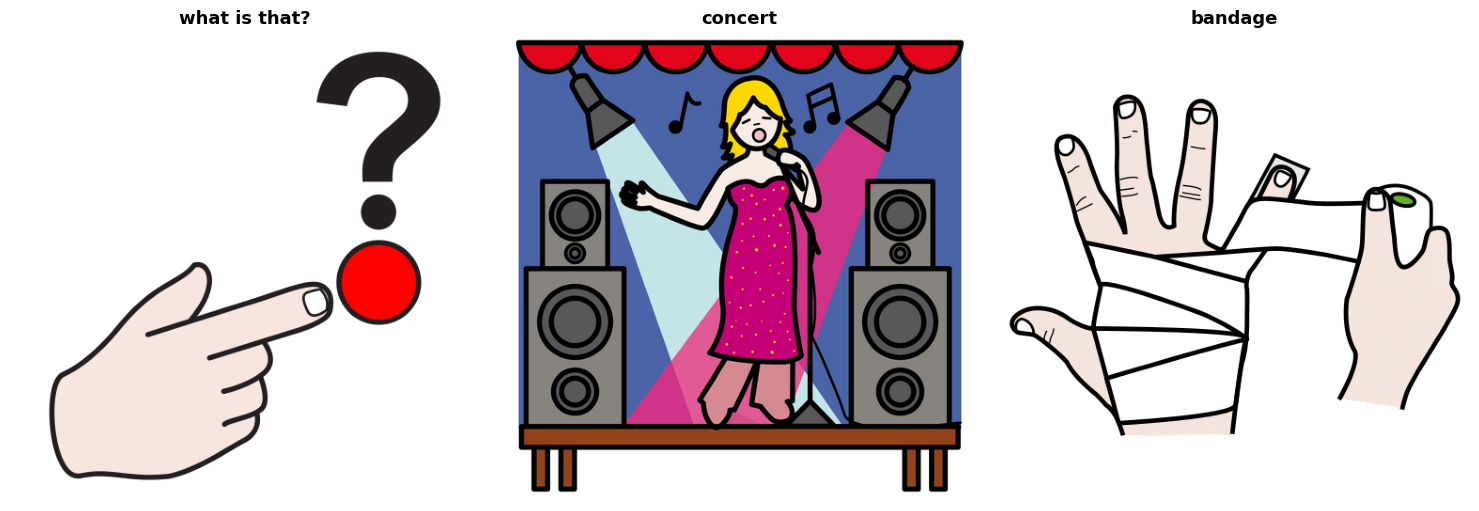

In [23]:
show_pictogram(df_images)

Here it is possible to see that pictograms can have multiple keywords, which, however are all very similar. This could be useful for the retrieval of pictograms. Sometimes there are no attributes in the keywords, tags or categories. Let's see for each column how many are these cases.

In [24]:
# check if there are any null values in the DataFrame
print(df_images.isnull().sum())

print("Number of total:", len(df_images))

image              0
pictogram_id       0
tags            1817
categories      1817
keywords        1817
dtype: int64
Number of total: 12474


So they are nearly 15% of the pictograms in the dataset. This could be a problem for doing a only keyword-based retrieval. However, the image-based retrieval should be able to retrieve also these pictograms, as they are not missing the image. For this reason a comparison between the two approaches will be done in the next steps.s

## 3. Text-based and image-based embeddings

### 3.1 Text-based embeddings

Let's begin by building a passages dataset for each of the pictograms. The embeddings with missing contribution will be left without the embedding. This is wanted to see how much the lack of the description affects the down stream tasks. In the retrieval step just the keywords will embedded in order to make the task less noisy, while descriptions will be used for the reranking step.

In [25]:
passages = []
for _, row in df_images.iterrows():
    pid     = int(row['pictogram_id'])
    kw_list = extract_keywords_list(row['keywords'])

    if kw_list:
        seen, unique = set(), []
        for p in kw_list:
            norm = normalize_phrase(p)
            if norm not in seen:
                seen.add(norm); unique.append(p)
        passages.append({"id": pid, "text": ', '.join(unique)})

print(f"Total passages: {len(passages)}")
print(f"Still unindexed: {len(df_images) - len(set(p['id'] for p in passages))}")
display(passages[:15])

Total passages: 10657
Still unindexed: 1817


[{'id': 10133, 'text': 'hang, put up'},
 {'id': 10135, 'text': 'oven'},
 {'id': 10137, 'text': 'open'},
 {'id': 10138, 'text': 'open your eyes'},
 {'id': 10139, 'text': 'group, classify, arrange, put into groups'},
 {'id': 10140, 'text': 'roast'},
 {'id': 10141, 'text': 'help, assist, attend to, attend, give aid to, aid'},
 {'id': 10142, 'text': 'take underpants off, take pants off, take shorts off'},
 {'id': 10143, 'text': 'take trousers off'},
 {'id': 10144, 'text': 'lower the toilet seat'},
 {'id': 10145, 'text': 'brush'},
 {'id': 10146, 'text': 'close, close the eyes, shut'},
 {'id': 10147, 'text': 'pick up toilet paper'},
 {'id': 10148, 'text': 'take, pick up'},
 {'id': 10149, 'text': 'cut the bread'}]

As expected the 1817 pictograms with the missing embedding will not be considered here. Now it is necessary creating the embeddings. In this case [Yuan-embedding-2.0-en](https://huggingface.co/IEITYuan/Yuan-embedding-2.0-en) embeddings will be used as they are considered to be the best embeddings for retrieval by the [MTEB leaderboard](https://huggingface.co/spaces/mteb/leaderboard). <br>
[Jina-embeddings-v5-omni-nano](https://huggingface.co/jinaai/jina-embeddings-v5-omni-nano) will be also used as it is one of the latest and most promising multimodal embedding models which will be also used later in the project for the image+text-based retrieval. The result of the text only retrieval will allow to see the difference when also the corresponding pictogram is also embedded.

In [26]:
REBUILD = False  # set True to drop collection, delete checkpoint and re-embed

yuan_client   = MilvusClient(uri="./BDATM/embeddings/yuan/yuan.db")
embedding_model_yuan = HuggingFaceEmbeddings(
    model_name="IEITYuan/Yuan-embedding-2.0-en",
    encode_kwargs={"normalize_embeddings": True}
)

passage_col_name  = "yuan_passage_collection"

if REBUILD:
    import os
    embedding_dim = len(embedding_model_yuan.embed_query("foo"))

    # drop and recreate collection
    if yuan_client.has_collection(passage_col_name):
        yuan_client.drop_collection(passage_col_name)
    yuan_client.create_collection(
        collection_name=passage_col_name,
        dimension=embedding_dim,
        consistency_level="Strong",
    )

    # delete checkpoint so embeddings are recomputed from scratch
    if os.path.exists(f"{passage_col_name}_embeddings.npy"):
        os.remove(f"{passage_col_name}_embeddings.npy")
        print("Checkpoint deleted — embeddings will be recomputed.")

    milvus_insert(milvus_client=yuan_client, collection_name=passage_col_name, text_list=passages, embedding_model=embedding_model_yuan)
    print("Rebuild complete.")
else:
    print(f"Connected. Collections: {yuan_client.list_collections()} with {yuan_client.get_collection_stats(passage_col_name)['row_count']} vectors), skipping.")



Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Connected. Collections: ['yuan_passage_collection'] with 10657 vectors), skipping.


In [27]:
REBUILD = False  # set True to drop collection, delete checkpoint and re-embed

jina_text_client   = MilvusClient(uri="./BDATM/embeddings/jina/jina_text/jina_nano.db")
jina_text_model = JinaEmbeddings("jinaai/jina-embeddings-v5-omni-nano")

passage_col_name  = "jina_passage_collection"

if REBUILD:
    import os
    embedding_dim = len(jina_text_model.embed_query("foo"))

    # drop and recreate collection
    if jina_text_client.has_collection(passage_col_name):
        jina_text_client.drop_collection(passage_col_name)
    jina_text_client.create_collection(
        collection_name=passage_col_name,
        dimension=embedding_dim,
        consistency_level="Strong",
    )

    # delete checkpoint so embeddings are recomputed from scratch
    if os.path.exists(f"{passage_col_name}_embeddings.npy"):
        os.remove(f"{passage_col_name}_embeddings.npy")
        print("Checkpoint deleted — embeddings will be recomputed.")

    milvus_insert(milvus_client=jina_text_client, collection_name=passage_col_name, text_list=passages, embedding_model=jina_text_model)
    print("Rebuild complete.")
else:
    print(f"Connected. Collections: {jina_text_client.list_collections()} with {jina_text_client.get_collection_stats(passage_col_name)['row_count']} vectors), skipping.")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/780 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

JinaEmbeddings loaded on mps
Connected. Collections: ['jina_passage_collection'] with 10657 vectors), skipping.


### 3.2 Image+text embeddings

As explained in the previous subsection, the model used for image+text retrieval is [Jina-embeddings-v5-omni-nano](https://huggingface.co/jinaai/jina-embeddings-v5-omni-nano), as it one of the most recent and smallest multi-modal embedding models. It is larger than the previously presented one, but it allows to embed all the pictograms in the dataset, even the one which do not have any metadata. <br>
However, it is necessary to say that this model was trained on a real images dataset, therefore it is not guaranteed to produce better results in this specific framework where the picotgrams are more similar to cartoons than real images.

In [28]:
REBUILD_JINA = False


jina_col_name  = "jina_nano_image_collection"
jina_image_client = MilvusClient(uri="./BDATM/embeddings/jina/jina_image/jina_image_nano.db")
jina_image_model = JinaEmbeddings("jinaai/jina-embeddings-v5-omni-nano")
JINA_DIM  = len(jina_image_model.embed_query("foo"))

if REBUILD_JINA or not jina_image_client.has_collection(jina_col_name):
    if jina_image_client.has_collection(jina_col_name):
        jina_image_client.drop_collection(jina_col_name)
    jina_image_client.create_collection(
        collection_name=jina_col_name,
        dimension=JINA_DIM,
    )
    BATCH = 32
    rows = df_images.reset_index(drop=True)
    for i in tqdm(range(0, len(rows), BATCH), desc="Embedding pictograms (jina-v5-nano)"):
        batch = rows.iloc[i : i + BATCH]
        pids      = [int(r['pictogram_id']) for _, r in batch.iterrows()]
        img_bytes = [r['image']['bytes'] for _, r in batch.iterrows()]
        try:
            img_vecs = jina_image_model.encode(img_bytes)  # (B, D)

            # collect keyword texts and their positions in the batch
            kw_texts, kw_idx = [], []
            for j, (_, r) in enumerate(batch.iterrows()):
                kws = extract_keywords_list(r['keywords'])
                if kws:
                    kw_texts.append(', '.join(kws))
                    kw_idx.append(j)

            # average image + keyword vectors where keywords exist
            if kw_texts:
                kw_vecs = jina_image_model.model.encode_document(kw_texts, normalize_embeddings=True)
                for k, j in enumerate(kw_idx):
                    combined = img_vecs[j] + kw_vecs[k]
                    img_vecs[j] = combined / np.linalg.norm(combined)

            jina_image_client.insert(
                collection_name=jina_col_name,
                data=[{"id": pid, "vector": vec.tolist()} for pid, vec in zip(pids, img_vecs)]
            )
        except Exception as e:
            print(f"Batch {i} failed: {e}")
    print("jina-v5-nano image index built.")
else:
    print(f"Connected. Collections: {jina_image_client.list_collections()} with {jina_image_client.get_collection_stats(jina_col_name)['row_count']} vectors), skipping.")


Loading weights:   0%|          | 0/780 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

JinaEmbeddings loaded on mps
Connected. Collections: ['jina_nano_image_collection'] with 12474 vectors), skipping.


## 4. Text-based and image-based retrieval

After producing the embeddings it is now possible to retrieve the pictograms. Here the retrieval will be done in the following way: a subset of sentences from `df_nosy_sentences` will be used as queries. For each query the corresponding concepts will be extracted and the pictograms associated to these concepts will be retrieved. The retrieved pictograms will be then evaluated with `Recall@k`. The value of k is decided in the following cell with an elbow plot. <br>
Here two types of evaluations are present: a "strict" one where just the ids of the pictograms in the corresponding `pictogram` entry for that given sentence are considered correct; a "relaxed" metric will be also presented where a pictogram will be considered corrected if it is in the `candidate` for a given sentence.<br>
The retrieval with LLM is has been called concept-based, here the LLM is used to extract n keywords from the sentence (typically 3 or 4) and this is the unfied in one unique query to match the style in which the passages where constructed. <br>
The retrieval will be done using the embeddings presented in the previous section, with the "noisy" sentences created by the LLM in section . For each embedding model three retrieval will be done:
- one with just the noisy sentence;
- one with the LLM polished retrieval;
- one with the WebLLM polished retrieval; <br>



After this the performances across all the possible combinations will be compared. The LLM used will be Qwen3.5:4B. For the WebLLM Qwen2.5-7B-Instruct as it was impossible to find a way to deactivate thinking in WebLLM, therefore a model without thinking was chosen. <br>
Here the LLMs will be loaded and then a first comparison across all 9 runs will be done. The best performing model will be then be compared thoroughly with a seed comparison. The best performing model(s) will be then used for the reranking step.

In [29]:
# Pull model
result = subprocess.run(['ollama', 'pull', 'qwen3.5:4b'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest 
pulling 81fb60c7daa8: 100% ▕██████████████████▏ 3.4 GB                         
pulling 7339fa418c9a: 100% ▕██████████████████▏  11 KB                         
pulling 9371364b27a5: 100% ▕██████████████████▏   65 B                         
pulling de9fed2251b3: 100% ▕██████████████████▏  475 B                         
verifying sha256 digest 
writing manifest 
success 



In [30]:
app, bridge_data, port = create_webllm_bridge("Qwen2.5-7B-Instruct-q4f16_1-MLC")

✅ Bridge Server active — model: Qwen2.5-7B-Instruct-q4f16_1-MLC * Serving Flask app 'BDATM.utils'

   local URL: http://localhost:52667
 * Debug mode: off


 * Running on http://127.0.0.1:52667
Press CTRL+C to quit


Now that the LLMs are loaded, let's see the results of the retrieval step.


Checkpoint loaded: 9 configs done
  [checkpoint] skipping Yuan (text)
  [checkpoint] skipping Jina nano (text)
  [checkpoint] skipping Jina nano (image+text)
  [checkpoint] skipping Yuan (text) + LLM simplified (Qwen2.5-7B-Instruct-q4f16_1-MLC)
  [checkpoint] skipping Jina nano (text) + LLM simplified (Qwen2.5-7B-Instruct-q4f16_1-MLC)
  [checkpoint] skipping Jina nano (image+text) + LLM simplified (Qwen2.5-7B-Instruct-q4f16_1-MLC)
  [checkpoint] skipping Yuan (text) + LLM simplified (qwen3.5:4b)
  [checkpoint] skipping Jina nano (text) + LLM simplified (qwen3.5:4b)
  [checkpoint] skipping Jina nano (image+text) + LLM simplified (qwen3.5:4b)


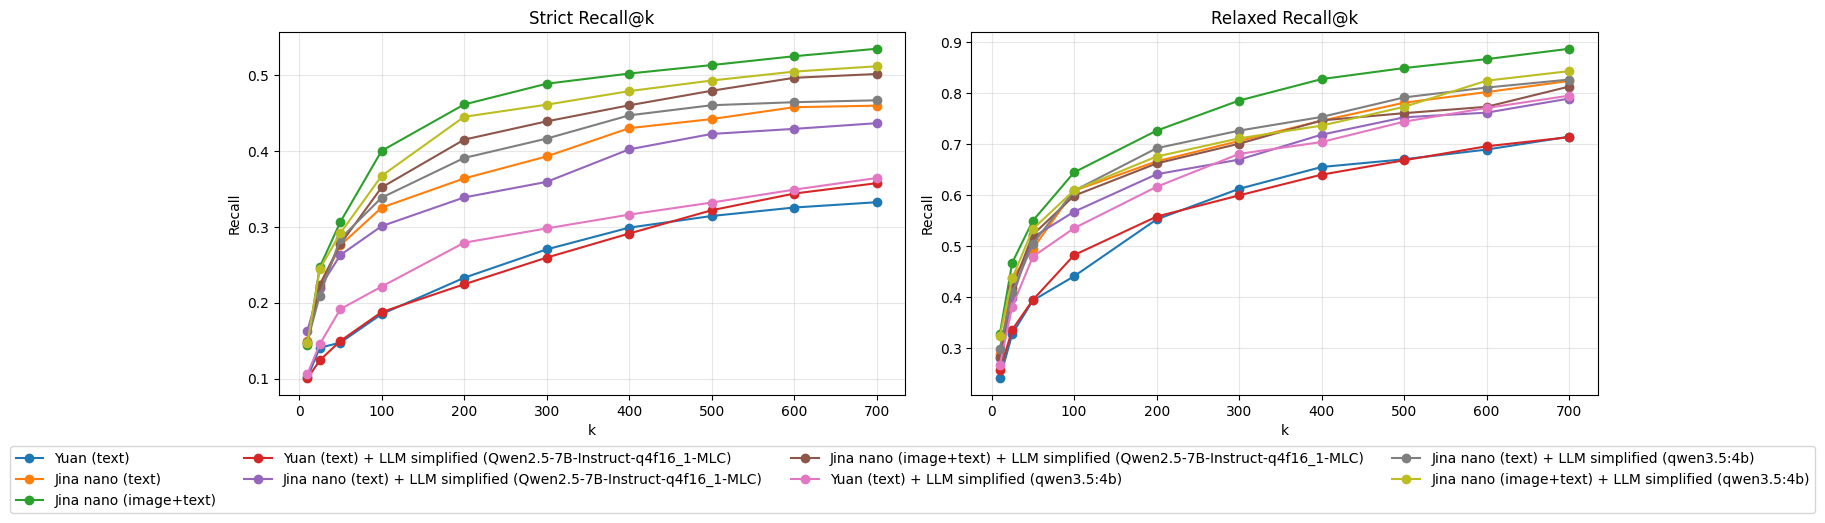

In [31]:
# model configurations for retrieval
retrieval_configs = [
    {
        'name': 'Yuan (text)',
        'client': yuan_client,
        'collection': 'yuan_passage_collection',
        'embed_fn': lambda q: embedding_model_yuan.embed_query(q),
    },
    {
        'name': 'Jina nano (text)',
        'client': jina_text_client,
        'collection': 'jina_passage_collection',
        'embed_fn': lambda q: jina_text_model.embed_query(q),
    },
    {
        'name': 'Jina nano (image+text)',
        'client': jina_image_client,
        'collection': 'jina_nano_image_collection',
        'embed_fn': lambda q: jina_image_model.embed_query(q),
    },
]

llm_configs = [{
       'name':      'WebLLM (Qwen2.5-7B-Instruct-q4f16_1-MLC)',
       'llm_model': 'Qwen2.5-7B-Instruct-q4f16_1-MLC',
       'backend':   'webllm',
       'bridge':    bridge_data,
},
    {
        'name':      'Ollama (qwen3:4b)',
        'llm_model': 'qwen3.5:4b',
        'backend':   'ollama',
    },


]

retrieval_configs_llm = retrieval_configs + [
    make_llm_simplify_config(cfg1, **cfg)
    for cfg in llm_configs
    for cfg1 in retrieval_configs # only text-based retrievals for LLM simplification
]

k_values = [10, 25, 50, 100, 200, 300, 400, 500, 600, 700]
# plot_recall_at_k — saves per model after each config completes
strict_df, relaxed_df = plot_recall_at_k(
    df_noisy_sentences, retrieval_configs_llm, k_values,
    n_samples=100, random_state=42,
    checkpoint_path="./BDATM/jsons/retrieval/recall_at_k_checkpoint_true.json"
)




The results are interesting. The best performing model is jina-embeddings-v5-omni-nano in the multimodal setting without the use of any LLM. This model seems to be significantly higher than all the other configurations. It is interesting to see that the jina-embeddings-v5-omni-nano's performances in both the text and image+text retrieval is hurted by the use of the LLMs, while the use of Qwen3.5:4B seems to improve the performances of the Yuan-embedding-2.0-en model. <br>
The WebLLM model seems to be not able to improve significantly the performances of the retrieval, even though it has a much larger latency. For this reason it will not be used in the following steps. <br>
In the next step all the embedding models will be tried in a configuration alone and also while using Qwen3.5:4B for the LLM polishing of the queries to see if the results seen here are significant. The best performing models will be then used for the reranking step.

Checkpoint loaded: 30 entries done

Random state: 42
  [checkpoint] skipping Yuan (text) (seed=42)
  [checkpoint] skipping Jina nano (text) (seed=42)
  [checkpoint] skipping Jina nano (image+text) (seed=42)
  [checkpoint] skipping Yuan (text) + LLM simplified (qwen3.5:4b) (seed=42)
  [checkpoint] skipping Jina nano (text) + LLM simplified (qwen3.5:4b) (seed=42)
  [checkpoint] skipping Jina nano (image+text) + LLM simplified (qwen3.5:4b) (seed=42)

Random state: 94
  [checkpoint] skipping Yuan (text) (seed=94)
  [checkpoint] skipping Jina nano (text) (seed=94)
  [checkpoint] skipping Jina nano (image+text) (seed=94)
  [checkpoint] skipping Yuan (text) + LLM simplified (qwen3.5:4b) (seed=94)
  [checkpoint] skipping Jina nano (text) + LLM simplified (qwen3.5:4b) (seed=94)
  [checkpoint] skipping Jina nano (image+text) + LLM simplified (qwen3.5:4b) (seed=94)

Random state: 10
  [checkpoint] skipping Yuan (text) (seed=10)
  [checkpoint] skipping Jina nano (text) (seed=10)
  [checkpoint] ski

,Model,Recall,Precision,F1,Relaxed Recall,Relaxed Precision,Relaxed F1
0,Jina nano (image+text),0.422 ± 0.035,0.005 ± 0.000,0.010 ± 0.001,0.749 ± 0.039,0.023 ± 0.001,0.044 ± 0.003
1,Jina nano (image+text) + LLM simplified (qwen3...,0.416 ± 0.035,0.005 ± 0.000,0.010 ± 0.001,0.716 ± 0.020,0.022 ± 0.001,0.042 ± 0.002
2,Jina nano (text),0.361 ± 0.024,0.004 ± 0.000,0.009 ± 0.001,0.684 ± 0.026,0.019 ± 0.001,0.036 ± 0.002
3,Jina nano (text) + LLM simplified (qwen3.5:4b),0.380 ± 0.024,0.005 ± 0.000,0.009 ± 0.001,0.710 ± 0.028,0.019 ± 0.001,0.037 ± 0.001
4,Yuan (text),0.242 ± 0.013,0.003 ± 0.000,0.006 ± 0.000,0.547 ± 0.024,0.011 ± 0.001,0.022 ± 0.002
5,Yuan (text) + LLM simplified (qwen3.5:4b),0.278 ± 0.020,0.003 ± 0.000,0.007 ± 0.000,0.633 ± 0.023,0.014 ± 0.001,0.027 ± 0.001


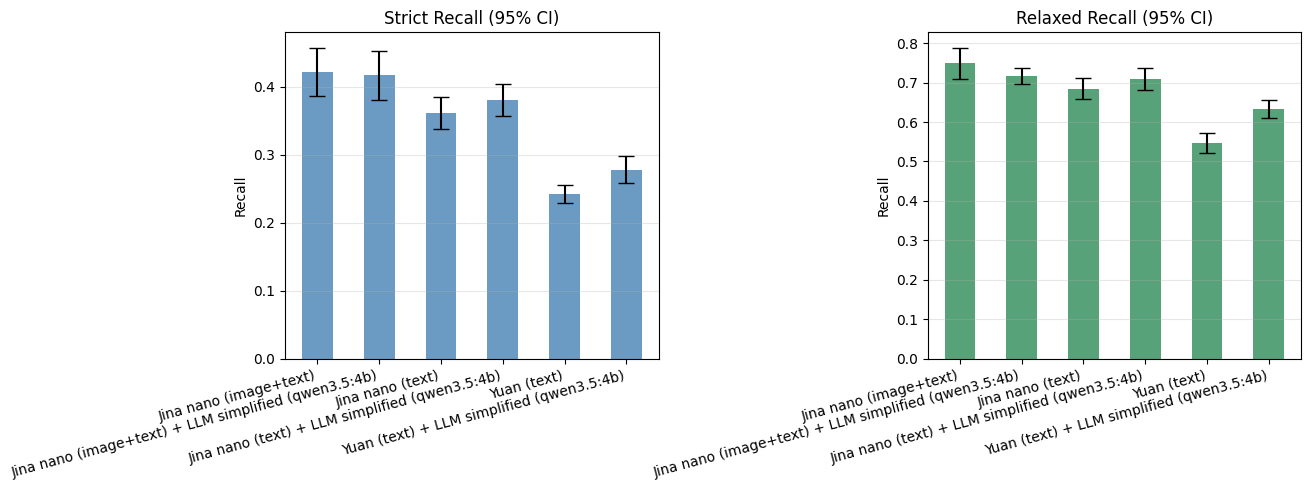

In [32]:
# model configurations for retrieval
retrieval_configs = [
    {
        'name': 'Yuan (text)',
        'client': yuan_client,
        'collection': 'yuan_passage_collection',
        'embed_fn': lambda q: embedding_model_yuan.embed_query(q),
    },
    {
        'name': 'Jina nano (text)',
        'client': jina_text_client,
        'collection': 'jina_passage_collection',
        'embed_fn': lambda q: jina_text_model.embed_query(q),
    },
    {
        'name': 'Jina nano (image+text)',
        'client': jina_image_client,
        'collection': 'jina_nano_image_collection',
        'embed_fn': lambda q: jina_image_model.embed_query(q),
    },
]

llm_configs = [
    {
        'name':      'Ollama (qwen3:4b)',
        'llm_model': 'qwen3.5:4b',
        'backend':   'ollama',
    },

]

selected_configs = retrieval_configs + [
    make_llm_simplify_config(cfg1, **cfg)
    for cfg in llm_configs
    for cfg1 in retrieval_configs
]

# evaluate_retrieval — saves per (seed, model) after each config completes
ret_runs_df, ret_summary = evaluate_retrieval(
    df_noisy_sentences, selected_configs,
    n_samples=200, random_states=[42, 94, 10, 239, 1732],
    k=300, plot=True,
    checkpoint_path="./BDATM/jsons/retrieval/eval_retrieval_checkpoint_true.json"
)


The performances shown in the previous graph are partially confirmed here. There is no significant difference between any of the jina-embeddings-v5-omni-nano configurations, while Yuan-embedding-2.0-en is significantly lower than both Jina variants. <br>
It is interesting to note that Qwen3.5:4B LLM simplification improves Yuan-embedding-2.0-en, with a statistically significant gain in relaxed recall and strict recall. This is likely due to the difference in retrieval symmetry: Yuan-embedding-2.0-en is a symmetric model not trained on noisy queries, so LLM polishing of the input helps bridge the query-document gap. In contrast, jina-embeddings-v5-omni-nano uses asymmetric retrieval, encoding queries and documents differently, making it inherently robust to noisy queries and leaving no room for LLM simplification to add value.

## 5. Reranking step

In this section the goal is to rerank the 400 pictograms retrieved in the previous step so that the correct ones appear at the top. To do this, as, in the step before, Large Language Model will be used to rewrite the query. Jut the two best models for the retrieval will be compared here: the Yuan-embedding-2.0-en on text retrieval and the Jina-embeddings-v5-omni-nano on image+text retrieval.<br>
The result of the reranking in 4 different pipelines will be compared:
- when the LLM rewritten query is just used for the retrieval step and the reranking is done with the original query;
- when the LLM rewritten query is used for both the retrieval and reranking step;
- when the LLM rewritten query is used for the reranking step and the retrieval is done with the original query;
- when the original query is used for both the retrieval and reranking step. <br>


For the reranking step, as before a Qwen3.5:4B model will be used for the LLM polishing. The WebLLM will not be used in this step due to the really high latency which did not resort to a major improvement of neither the "strict" or the "relaxed" recall. <br>

### 5.1 Load the two rerankers

Two rerankers will be compared here, as, in the step before, to rerank the pictograms retrieved: ms-marco-MiniLM-L12-v2 (lightweight cross-encoder, ~15M params, trained on MS Marco Passage Ranking) and jina-reranker-v3 (0.6B param multilingual reranker built on Qwen3-0.6B, using a "last but not late interaction" architecture, supporting up to 64 documents jointly).<br>
This pairing contrasts a small, fast, proven cross-encoder against a larger, newer, listwise-capable model, to test whether the added scale/architecture complexity yields meaningful gains for this task. <br>

In [33]:
_ce_device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"CrossEncoder device: {_ce_device}")

# jina-reranker-v3 is a *listwise* reranker (causal self-attention over the
# query and ALL documents jointly, scoring from the last token of each doc).
# It is NOT a pointwise CrossEncoder and must NOT be loaded via CrossEncoder
# / .predict((query, doc)) pairs -- that silently crashes per-pair (0-length
# tensor reshape) and rerank_pictograms was falling back to a constant 0.0
# score for every candidate, making reranking a no-op. Use the native
# AutoModel + .rerank(query, documents) API instead.
from transformers import AutoModel
text_reranker1 = AutoModel.from_pretrained(
    "jinaai/jina-reranker-v3", dtype="auto", trust_remote_code=True
).to(_ce_device)
text_reranker1.eval()

text_reranker2 = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2",
                              device=_ce_device, trust_remote_code=True)

CrossEncoder device: mps


modeling.py:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-reranker-v3:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Loading weights:   0%|          | 0/312 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/202 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Now add also vision reranker which uses the pictograms for reranking. As this is much more resource-intensive then it will be run on a small sample for just one seed. If the performance will be promising, it will indicative of further investingating its use in the future.

In [35]:
for key in list(sys.modules.keys()):
    if 'qwen3_vl_reranker' in key or key == 'utils':
        del sys.modules[key]

vl_reranker = QwenVLReranker(
    model_name_or_path="Qwen/Qwen3-VL-Reranker-2B",
    scripts_dir="./BDATM/qwen_vl_reranker_repo",
    device_map=_ce_device,
    torch_dtype=torch.float16,
)

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

QwenVLReranker loaded from Qwen/Qwen3-VL-Reranker-2B


Make a small change in the compute score function to allow for the use of the vision reranker.

In [36]:
def _patched_compute_scores(self, inputs):
    target_device = inputs['input_ids'].device
    if 'mm_token_type_ids' in inputs:
        mtt = inputs['mm_token_type_ids']
        if not isinstance(mtt, torch.Tensor):
            mtt = torch.tensor(mtt, device=target_device)
        else:
            mtt = mtt.to(target_device)
        if mtt.dim() == 1:
            mtt = mtt.unsqueeze(0)
        inputs['mm_token_type_ids'] = mtt
    model_device = next(self.model.parameters()).device
    if model_device != target_device:
        self.model.to(target_device)
        self.score_linear.to(target_device)
    batch_scores = self.model(**inputs).last_hidden_state[:, -1]
    scores = self.score_linear(batch_scores)
    scores = torch.sigmoid(scores).squeeze(-1).cpu().detach().tolist()
    return scores

import types
vl_reranker._model.compute_scores = types.MethodType(_patched_compute_scores, vl_reranker._model)
print("Monkey-patched.")

Monkey-patched.


### 5.2 Use the rerankers together with the LLMs to rerank the retrieved pictograms

After loading the rerankers, now  the look-up dictionaries for the two rerankers are built. The one shown here maps each pictogram id to its keyword text string (used by jina-reranker-v3 to score (query, keywords) pairs). This allowsto retrieve the right content for each candidate id in O(1) time. As before the keywords are used as this gave better empirical results. <br>

In [37]:
pid_to_description: dict[int, str] = {}
for _, row in df_images.iterrows():
    pid = int(row['pictogram_id'])
    kws = row['keywords']

    kw_list = extract_keywords_list(kws)
    if not kw_list:
        continue

    kws_list = kws.tolist() if isinstance(kws, np.ndarray) else (kws if isinstance(kws, list) else [])
    parts = []
    for kw in kws_list:
        if not isinstance(kw, dict):
            continue
        meaning = kw.get('meaning')
        keyword = kw.get('keyword', '')
        #if meaning and not is_unusable_description(meaning):
        #    parts.append(meaning)
        if keyword and not is_unusable_description(keyword):
            parts.append(keyword)

    if parts:
        pid_to_description[pid] = '. '.join(parts)

print(len(pid_to_description), "pictograms with descriptions found in the images dataset.")

10635 pictograms with descriptions found in the images dataset.


In [38]:
pid_to_image: dict[int, dict] = {}
for _, row in df_images.iterrows():
    pid = int(row['pictogram_id'])
    img = row['image']
    if img is None:
        continue
    pid_to_image[pid] = {
        'bytes':    img['bytes'],
        'keywords': pid_to_description.get(pid, ''),  # reuse what's already built
    }

print(len(pid_to_image), "pictograms with images found.")

12464 pictograms with images found.


Now let's run the configurations for the all the embedding model withthe two text rerankers: jina-reranker-v3 and ms-marco-MiniLM-L12-v2. Here just Qwen3.5:4B with Ollama backend will be used as it was the best performing LLM in the retrieval step.

In [39]:
llm_configs = [
    {
        'name':      'Ollama (qwen3:4b)',
        'llm_model': 'qwen3.5:4b',
        'backend':   'ollama',
    },
]

Checkpoint loaded: 20 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.129   0.302
Recall@30 (CE rerank (noisy pool))                        : 0.126   0.305
Recall@30 (LLM rerank (noisy pool))                       : 0.166   0.364
Recall@30 (Pool (LLM polished))                           : 0.147   0.362
Recall@30 (CE rerank (LLM pool))                          : 0.144   0.312
Recall@30 (CE rerank (LLM polished))                      : 0.134   0.316

Seed: 94
  [checkpoint] skipping baselines (seed=94)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=94)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.119   0.295
Recall@30 (CE rerank (noisy pool))                        : 0.116   0.292
Recall@30 (LLM rerank (noisy pool))                       : 0.165   0.347
Recall@30 (Pool (LLM polished))                           : 0.161   0.328
Recall@30 (CE rerank (LLM pool))                          : 0.131   0.344
Recall@30 (CE rerank (LLM polished))                      : 0.138   0.336

Seed: 10
  [checkpoint] skipping baselines (seed=10)


...

building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=239)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.107   0.255
Recall@30 (CE rerank (noisy pool))                        : 0.123   0.253
Recall@30 (LLM rerank (noisy pool))                       : 0.159   0.322
Recall@30 (Pool (LLM polished))                           : 0.147   0.332
Recall@30 (CE rerank (LLM pool))                          : 0.136   0.273
Recall@30 (CE rerank (LLM polished))                      : 0.128   0.271

Seed: 1732
  [checkpoint] skipping baselines (seed=1732)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=1732)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.108   0.252
Recall@30 (CE rerank (noisy pool))                        : 0.106   0.237
Recall@30 (LLM rerank (noisy pool))                       : 0.134   0.282
Recall@30 (Pool (LLM polished))                           : 0.143   0.299
Recall@30 (CE rerank (LLM pool))                          : 0.118   0.260
Recall@30 (CE rerank (LLM polished))                      : 0.115   0.280

Results (mean ± 95% CI across 5 seed(s), t df=4):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.154 ± 0.017,0.326 ± 0.039
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.134 ± 0.013,0.301 ± 0.043
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.128 ± 0.011,0.302 ± 0.033
3,Ollama (qwen3:4b),Pool (noisy),0.116 ± 0.011,0.276 ± 0.028
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.120 ± 0.011,0.275 ± 0.036
5,Ollama (qwen3:4b),Pool (LLM polished),0.152 ± 0.011,0.340 ± 0.038


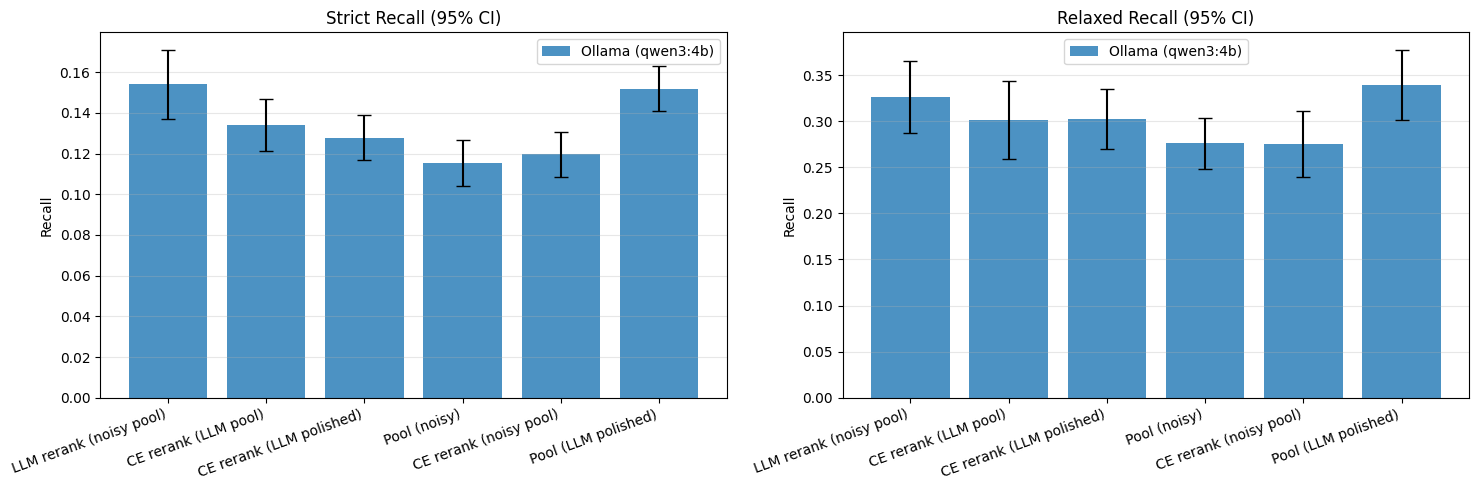

In [40]:
# Pipeline 1 — Yuan text retrieval + CE text reranker (jina-reranker-v3)
results_pipeline_yuan_jina = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=yuan_client, collection='yuan_passage_collection',
        embed_fn=embedding_model_yuan.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_description=pid_to_description, text_reranker=text_reranker1),
    pid_to_description=pid_to_description,
    n_samples=200, pool_k=300, rerank_n=30,
    random_states=[42, 94, 10, 239, 1732],
    modes=["llm_simplify", "llm_simplify_retrieve_only", "llm_simplify_retrieve"],
    show_baselines=True,
    plot=False, checkpoint_path='./BDATM/jsons/reranking/yuan_jina_checkpoint_1.json'
)



Checkpoint loaded: 20 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.129   0.302
Recall@30 (CE rerank (noisy pool))                        : 0.167   0.354
Recall@30 (LLM rerank (noisy pool))                       : 0.175   0.382
Recall@30 (Pool (LLM polished))                           : 0.147   0.362
Recall@30 (CE rerank (LLM pool))                          : 0.182   0.384
Recall@30 (CE rerank (LLM polished))                      : 0.175   0.375

Seed: 94
  [checkpoint] skipping baselines (seed=94)


building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=94)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.119   0.295
Recall@30 (CE rerank (noisy pool))                        : 0.157   0.351
Recall@30 (LLM rerank (noisy pool))                       : 0.169   0.373
Recall@30 (Pool (LLM polished))                           : 0.161   0.328
Recall@30 (CE rerank (LLM pool))                          : 0.183   0.389
Recall@30 (CE rerank (LLM polished))                      : 0.188   0.389

Seed: 10
  [checkpoint] skipping baselines (seed=10)


...

building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=239)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.107   0.255
Recall@30 (CE rerank (noisy pool))                        : 0.174   0.359
Recall@30 (LLM rerank (noisy pool))                       : 0.168   0.342
Recall@30 (Pool (LLM polished))                           : 0.147   0.332
Recall@30 (CE rerank (LLM pool))                          : 0.184   0.356
Recall@30 (CE rerank (LLM polished))                      : 0.164   0.334

Seed: 1732
  [checkpoint] skipping baselines (seed=1732)


building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=1732)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.108   0.252
Recall@30 (CE rerank (noisy pool))                        : 0.158   0.308
Recall@30 (LLM rerank (noisy pool))                       : 0.158   0.320
Recall@30 (Pool (LLM polished))                           : 0.143   0.299
Recall@30 (CE rerank (LLM pool))                          : 0.163   0.315
Recall@30 (CE rerank (LLM polished))                      : 0.166   0.322

Results (mean ± 95% CI across 5 seed(s), t df=4):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.165 ± 0.011,0.352 ± 0.031
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.178 ± 0.011,0.363 ± 0.037
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.172 ± 0.012,0.357 ± 0.035
3,Ollama (qwen3:4b),Pool (noisy),0.116 ± 0.011,0.276 ± 0.028
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.163 ± 0.009,0.341 ± 0.026
5,Ollama (qwen3:4b),Pool (LLM polished),0.152 ± 0.011,0.340 ± 0.038


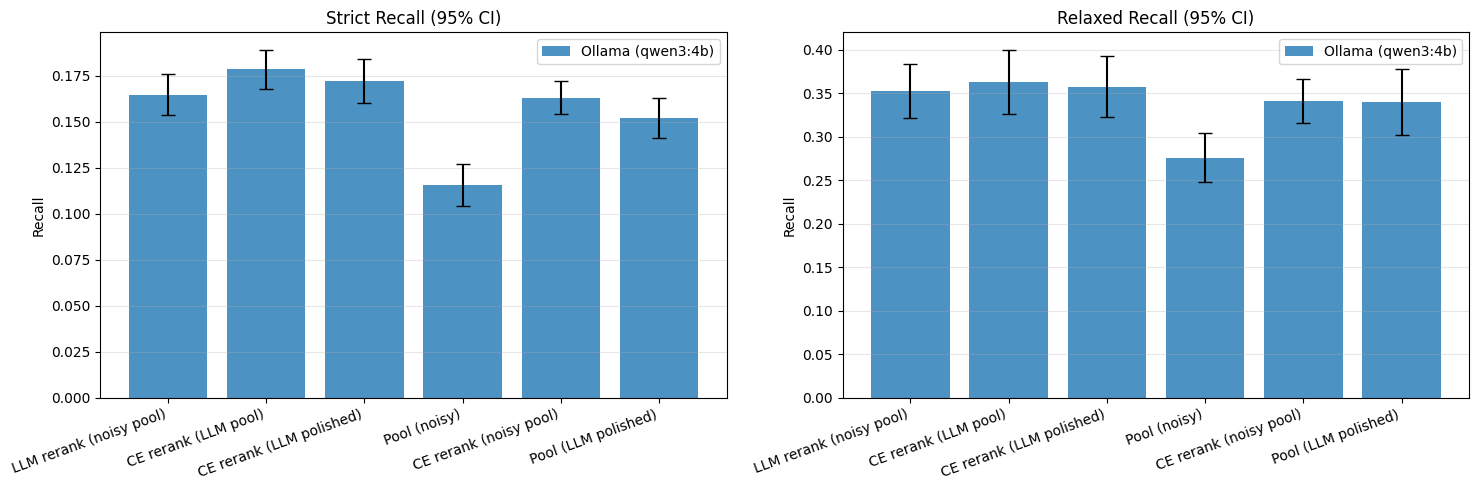

In [ ]:
# Pipeline 2 — Yuan text retrieval + CE text reranker (ms-marco-MiniLM-L-12-v2)
results_pipeline_yuan_marco = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=yuan_client, collection='yuan_passage_collection',
        embed_fn=embedding_model_yuan.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_description=pid_to_description, text_reranker=text_reranker2),
    pid_to_description=pid_to_description,
    n_samples=200, pool_k=300, rerank_n=30,
    random_states=[42, 94, 10, 239, 1732],
    show_baselines=True,
    plot=False, checkpoint_path='./BDATM/jsons/reranking/yuan_marco_checkpoint_2.json'
)

Checkpoint loaded: 20 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.212   0.415
Recall@30 (CE rerank (noisy pool))                        : 0.106   0.237
Recall@30 (LLM rerank (noisy pool))                       : 0.145   0.327
Recall@30 (Pool (LLM polished))                           : 0.215   0.427
Recall@30 (CE rerank (LLM pool))                          : 0.119   0.301
Recall@30 (CE rerank (LLM polished))                      : 0.119   0.284

Seed: 94
  [checkpoint] skipping baselines (seed=94)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=94)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.216   0.390
Recall@30 (CE rerank (noisy pool))                        : 0.111   0.257
Recall@30 (LLM rerank (noisy pool))                       : 0.156   0.343
Recall@30 (Pool (LLM polished))                           : 0.232   0.410
Recall@30 (CE rerank (LLM pool))                          : 0.126   0.321
Recall@30 (CE rerank (LLM polished))                      : 0.113   0.280

Seed: 10
  [checkpoint] skipping baselines (seed=10)


...

building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=239)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.218   0.426
Recall@30 (CE rerank (noisy pool))                        : 0.106   0.226
Recall@30 (LLM rerank (noisy pool))                       : 0.141   0.279
Recall@30 (Pool (LLM polished))                           : 0.207   0.409
Recall@30 (CE rerank (LLM pool))                          : 0.140   0.316
Recall@30 (CE rerank (LLM polished))                      : 0.129   0.277

Seed: 1732
  [checkpoint] skipping baselines (seed=1732)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=1732)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.200   0.359
Recall@30 (CE rerank (noisy pool))                        : 0.089   0.218
Recall@30 (LLM rerank (noisy pool))                       : 0.141   0.290
Recall@30 (Pool (LLM polished))                           : 0.203   0.389
Recall@30 (CE rerank (LLM pool))                          : 0.114   0.272
Recall@30 (CE rerank (LLM polished))                      : 0.109   0.263

Results (mean ± 95% CI across 5 seed(s), t df=4):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.144 ± 0.009,0.313 ± 0.034
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.128 ± 0.015,0.304 ± 0.025
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.118 ± 0.010,0.281 ± 0.017
3,Ollama (qwen3:4b),Pool (noisy),0.211 ± 0.009,0.400 ± 0.032
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.102 ± 0.011,0.234 ± 0.018
5,Ollama (qwen3:4b),Pool (LLM polished),0.212 ± 0.015,0.412 ± 0.019


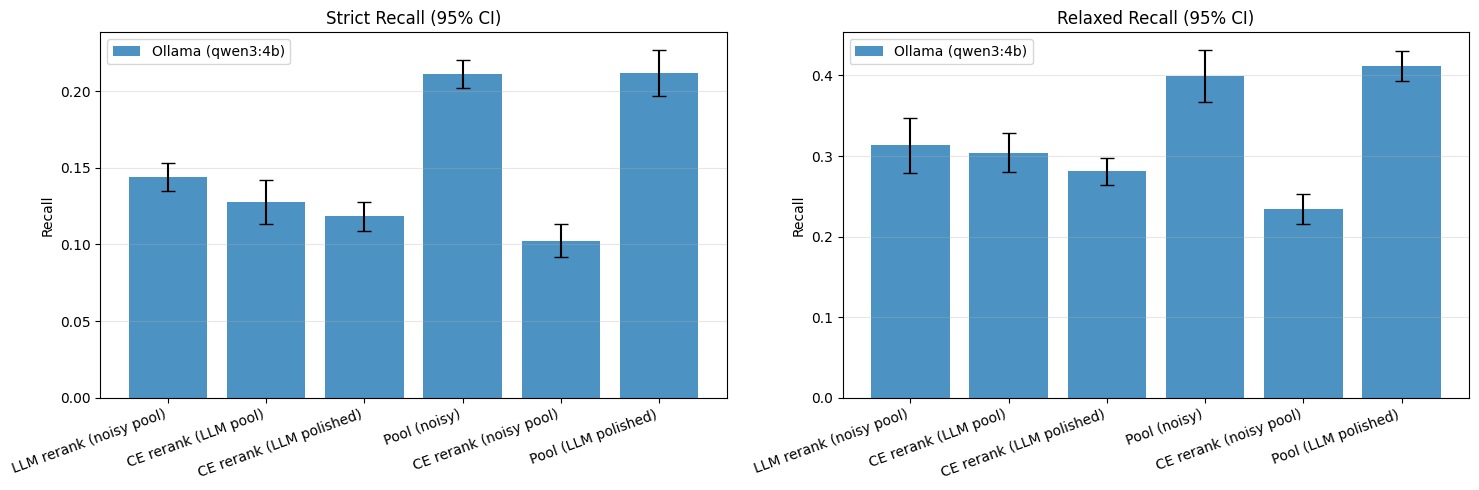

In [42]:
# Pipeline 3 — Jina text retrieval + CE text reranker (jina-reranker-v3)
results_pipeline_jina_text_jina = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=jina_text_client, collection='jina_passage_collection',
        embed_fn=jina_text_model.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_description=pid_to_description, text_reranker=text_reranker1),
    pid_to_description=pid_to_description,
    n_samples=200, pool_k=300, rerank_n=30,
    random_states=[42, 94, 10, 239, 1732],
    modes=["llm_simplify", "llm_simplify_retrieve_only", "llm_simplify_retrieve"],
    show_baselines=True,
    plot=False, checkpoint_path='./BDATM/jsons/reranking/jina_text_jina_reranker_checkpoint_3.json'
)


Checkpoint loaded: 20 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.212   0.415
Recall@30 (CE rerank (noisy pool))                        : 0.189   0.405
Recall@30 (LLM rerank (noisy pool))                       : 0.206   0.424
Recall@30 (Pool (LLM polished))                           : 0.215   0.427
Recall@30 (CE rerank (LLM pool))                          : 0.203   0.416
Recall@30 (CE rerank (LLM polished))                      : 0.199   0.404

Seed: 94
  [checkpoint] skipping baselines (seed=94)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=94)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.216   0.390
Recall@30 (CE rerank (noisy pool))                        : 0.193   0.409
Recall@30 (LLM rerank (noisy pool))                       : 0.206   0.427
Recall@30 (Pool (LLM polished))                           : 0.232   0.410
Recall@30 (CE rerank (LLM pool))                          : 0.201   0.420
Recall@30 (CE rerank (LLM polished))                      : 0.200   0.406

Seed: 10
  [checkpoint] skipping baselines (seed=10)


...

building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=239)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.218   0.426
Recall@30 (CE rerank (noisy pool))                        : 0.203   0.404
Recall@30 (LLM rerank (noisy pool))                       : 0.194   0.394
Recall@30 (Pool (LLM polished))                           : 0.207   0.409
Recall@30 (CE rerank (LLM pool))                          : 0.208   0.400
Recall@30 (CE rerank (LLM polished))                      : 0.190   0.378

Seed: 1732
  [checkpoint] skipping baselines (seed=1732)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=1732)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.200   0.359
Recall@30 (CE rerank (noisy pool))                        : 0.171   0.336
Recall@30 (LLM rerank (noisy pool))                       : 0.183   0.373
Recall@30 (Pool (LLM polished))                           : 0.203   0.389
Recall@30 (CE rerank (LLM pool))                          : 0.183   0.369
Recall@30 (CE rerank (LLM polished))                      : 0.178   0.359

Results (mean ± 95% CI across 5 seed(s), t df=4):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.193 ± 0.017,0.401 ± 0.029
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.197 ± 0.013,0.398 ± 0.026
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.189 ± 0.013,0.388 ± 0.024
3,Ollama (qwen3:4b),Pool (noisy),0.211 ± 0.009,0.400 ± 0.032
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.189 ± 0.014,0.388 ± 0.038
5,Ollama (qwen3:4b),Pool (LLM polished),0.212 ± 0.015,0.412 ± 0.019


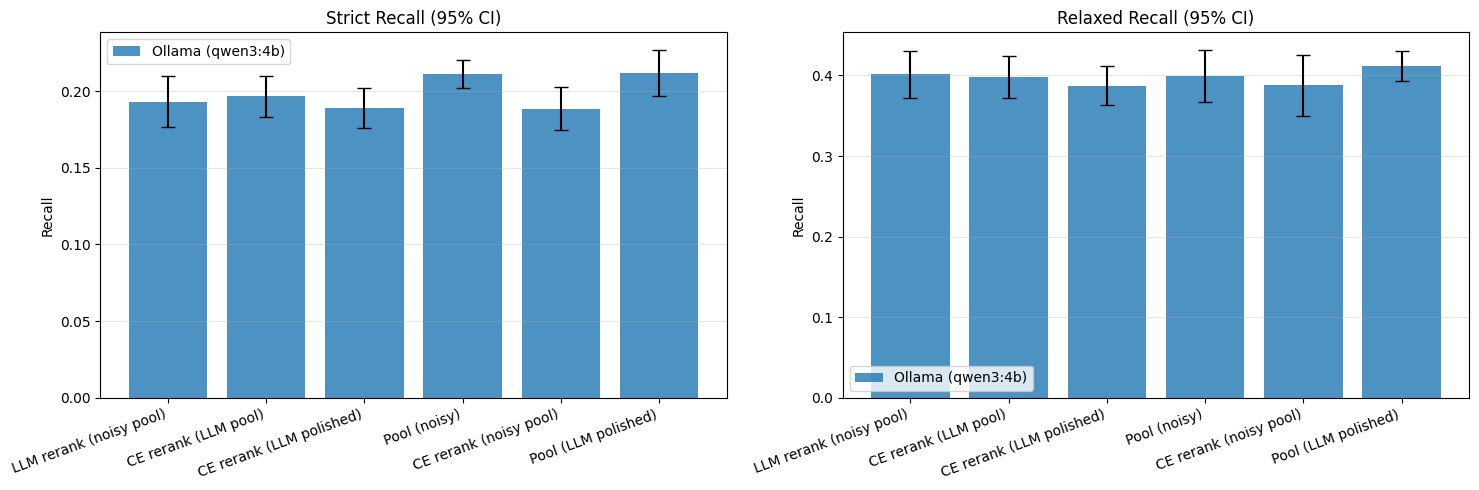

In [43]:
# Pipeline 4 — Jina text retrieval + CE text reranker (ms-marco-MiniLM-L-12-v2)
results_pipeline_jina_text_marco = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=jina_text_client, collection='jina_passage_collection',
        embed_fn=jina_text_model.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_description=pid_to_description, text_reranker=text_reranker2),
    pid_to_description=pid_to_description,
    n_samples=200, pool_k=300, rerank_n=30,
    random_states=[42, 94, 10, 239, 1732],
    show_baselines=True,
    plot=False, checkpoint_path='./BDATM/jsons/reranking/jina_text_marco_checkpoint_4.json'
)

Checkpoint loaded: 20 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.234   0.481
Recall@30 (CE rerank (noisy pool))                        : 0.118   0.312
Recall@30 (LLM rerank (noisy pool))                       : 0.157   0.350
Recall@30 (Pool (LLM polished))                           : 0.240   0.446
Recall@30 (CE rerank (LLM pool))                          : 0.139   0.329
Recall@30 (CE rerank (LLM polished))                      : 0.141   0.322

Seed: 94
  [checkpoint] skipping baselines (seed=94)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=94)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.233   0.450
Recall@30 (CE rerank (noisy pool))                        : 0.117   0.305
Recall@30 (LLM rerank (noisy pool))                       : 0.158   0.331
Recall@30 (Pool (LLM polished))                           : 0.238   0.432
Recall@30 (CE rerank (LLM pool))                          : 0.144   0.328
Recall@30 (CE rerank (LLM polished))                      : 0.143   0.321

Seed: 10
  [checkpoint] skipping baselines (seed=10)


...

building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=239)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.236   0.448
Recall@30 (CE rerank (noisy pool))                        : 0.137   0.297
Recall@30 (LLM rerank (noisy pool))                       : 0.144   0.298
Recall@30 (Pool (LLM polished))                           : 0.216   0.407
Recall@30 (CE rerank (LLM pool))                          : 0.142   0.320
Recall@30 (CE rerank (LLM polished))                      : 0.136   0.293

Seed: 1732
  [checkpoint] skipping baselines (seed=1732)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=1732)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.208   0.387
Recall@30 (CE rerank (noisy pool))                        : 0.124   0.289
Recall@30 (LLM rerank (noisy pool))                       : 0.137   0.309
Recall@30 (Pool (LLM polished))                           : 0.215   0.378
Recall@30 (CE rerank (LLM pool))                          : 0.134   0.327
Recall@30 (CE rerank (LLM polished))                      : 0.128   0.318

Results (mean ± 95% CI across 5 seed(s), t df=4):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.147 ± 0.012,0.324 ± 0.026
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.143 ± 0.012,0.331 ± 0.013
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.136 ± 0.007,0.313 ± 0.015
3,Ollama (qwen3:4b),Pool (noisy),0.226 ± 0.016,0.438 ± 0.043
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.123 ± 0.011,0.297 ± 0.014
5,Ollama (qwen3:4b),Pool (LLM polished),0.224 ± 0.017,0.416 ± 0.032


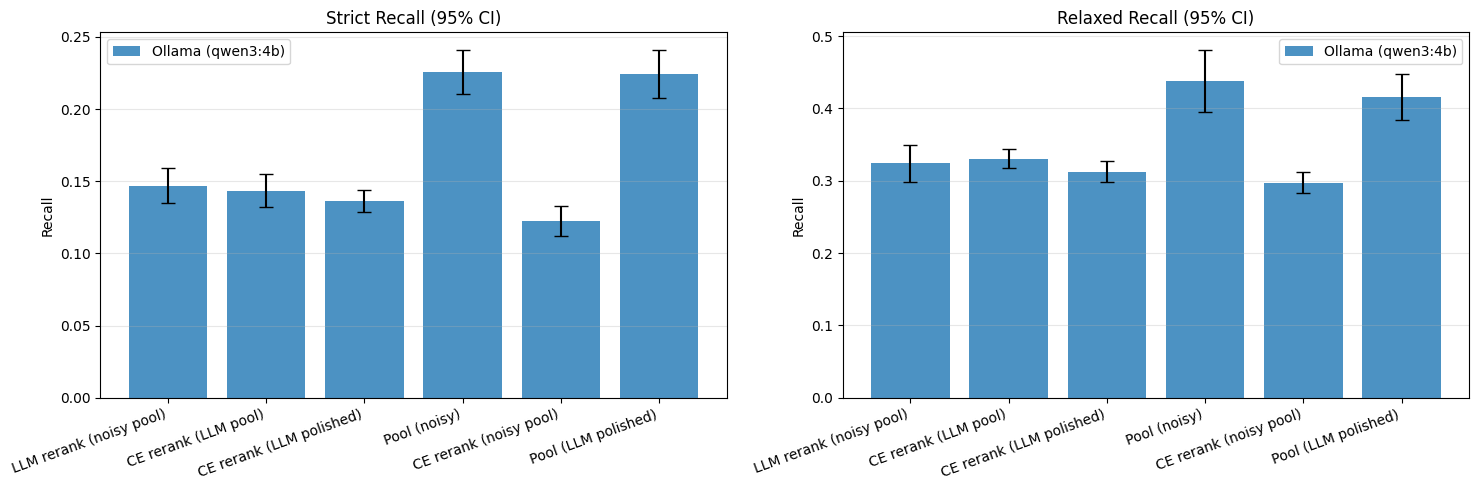

In [44]:
# Pipeline 5 — Jina image+text retrieval + CE text reranker (jina-reranker-v3)
results_pipeline_jina_image_jina = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=jina_image_client, collection='jina_nano_image_collection',
        embed_fn=jina_image_model.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_description=pid_to_description, text_reranker=text_reranker1),
    pid_to_description=pid_to_description,
    n_samples=200, pool_k=300, rerank_n=30,
    random_states=[42, 94, 10, 239, 1732],
    modes=["llm_simplify", "llm_simplify_retrieve_only", "llm_simplify_retrieve"],
    show_baselines=True,
    plot=False, checkpoint_path='./BDATM/jsons/reranking/jina_image_jina_reranker_checkpoint_5.json'
)


Checkpoint loaded: 20 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.234   0.481
Recall@30 (CE rerank (noisy pool))                        : 0.198   0.414
Recall@30 (LLM rerank (noisy pool))                       : 0.216   0.442
Recall@30 (Pool (LLM polished))                           : 0.240   0.446
Recall@30 (CE rerank (LLM pool))                          : 0.213   0.429
Recall@30 (CE rerank (LLM polished))                      : 0.204   0.415

Seed: 94
  [checkpoint] skipping baselines (seed=94)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=94)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=94)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.233   0.450
Recall@30 (CE rerank (noisy pool))                        : 0.202   0.416
Recall@30 (LLM rerank (noisy pool))                       : 0.209   0.447
Recall@30 (Pool (LLM polished))                           : 0.238   0.432
Recall@30 (CE rerank (LLM pool))                          : 0.205   0.430
Recall@30 (CE rerank (LLM polished))                      : 0.206   0.414

Seed: 10
  [checkpoint] skipping baselines (seed=10)


...

building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=239)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=239)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.236   0.448
Recall@30 (CE rerank (noisy pool))                        : 0.203   0.407
Recall@30 (LLM rerank (noisy pool))                       : 0.196   0.400
Recall@30 (Pool (LLM polished))                           : 0.216   0.407
Recall@30 (CE rerank (LLM pool))                          : 0.211   0.417
Recall@30 (CE rerank (LLM polished))                      : 0.193   0.375

Seed: 1732
  [checkpoint] skipping baselines (seed=1732)


building cache:   0%|          | 0/200 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=1732)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=1732)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.208   0.387
Recall@30 (CE rerank (noisy pool))                        : 0.181   0.340
Recall@30 (LLM rerank (noisy pool))                       : 0.188   0.379
Recall@30 (Pool (LLM polished))                           : 0.218   0.381
Recall@30 (CE rerank (LLM pool))                          : 0.187   0.375
Recall@30 (CE rerank (LLM polished))                      : 0.183   0.372

Results (mean ± 95% CI across 5 seed(s), t df=4):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.198 ± 0.019,0.414 ± 0.037
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.202 ± 0.014,0.410 ± 0.029
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.193 ± 0.015,0.394 ± 0.025
3,Ollama (qwen3:4b),Pool (noisy),0.226 ± 0.016,0.438 ± 0.043
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.196 ± 0.011,0.395 ± 0.039
5,Ollama (qwen3:4b),Pool (LLM polished),0.225 ± 0.016,0.416 ± 0.031


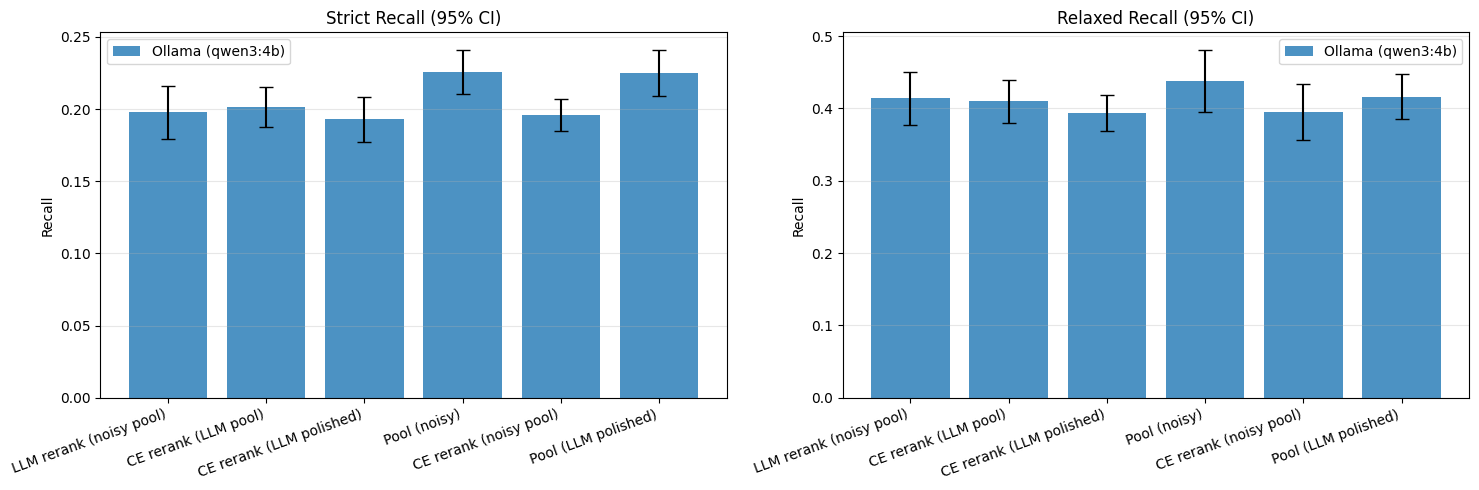

In [45]:
# Pipeline 6 — Jina image+text retrieval + CE text reranker (ms-marco-MiniLM-L-12-v2)
results_pipeline_jina_image_marco = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=jina_image_client, collection='jina_nano_image_collection',
        embed_fn=jina_image_model.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_description=pid_to_description, text_reranker=text_reranker2),
    pid_to_description=pid_to_description,
    n_samples=200, pool_k=300, rerank_n=30,
    random_states=[42, 94, 10, 239, 1732],
    show_baselines=True,
    plot=False, checkpoint_path='./BDATM/jsons/reranking/jina_image_marco_checkpoint_6.json'
)


Pipeline comparison (mean ± 95% CI across up to 5 seed(s), t df=4):


,Pipeline,Mode,Strict Recall,Relaxed Recall
0,Yuan + jina-reranker-v3,Pool (noisy),0.116 ± 0.011,0.276 ± 0.028
1,Yuan + jina-reranker-v3,CE rerank (noisy pool),0.120 ± 0.011,0.275 ± 0.036
2,Yuan + jina-reranker-v3,LLM rerank (noisy pool),0.154 ± 0.017,0.326 ± 0.039
3,Yuan + jina-reranker-v3,CE rerank (LLM pool),0.134 ± 0.013,0.301 ± 0.043
4,Yuan + jina-reranker-v3,CE rerank (LLM polished),0.128 ± 0.011,0.302 ± 0.033
5,Yuan + jina-reranker-v3,Pool (LLM polished),0.152 ± 0.011,0.340 ± 0.038
6,Yuan + ms-marco-MiniLM,Pool (noisy),0.116 ± 0.011,0.276 ± 0.028
7,Yuan + ms-marco-MiniLM,CE rerank (noisy pool),0.163 ± 0.009,0.341 ± 0.026
8,Yuan + ms-marco-MiniLM,LLM rerank (noisy pool),0.165 ± 0.011,0.352 ± 0.031
9,Yuan + ms-marco-MiniLM,CE rerank (LLM pool),0.178 ± 0.011,0.363 ± 0.037


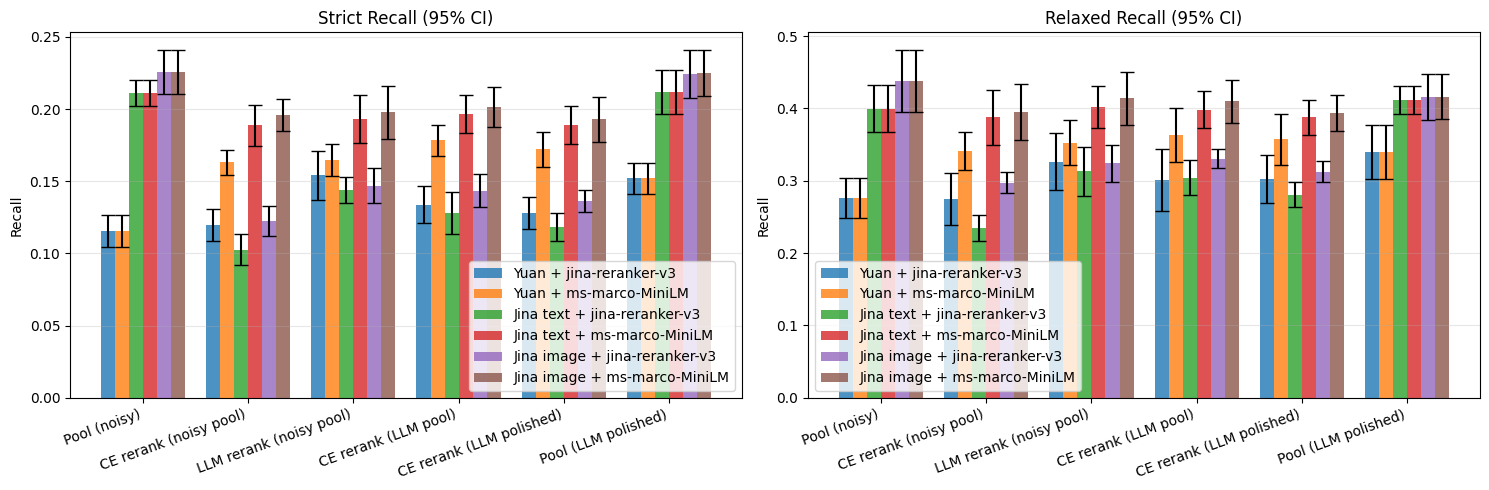

In [46]:
# Compare all 6 text-reranker pipelines (Pipelines 1-6) side by side, loading
# straight from the saved checkpoints -- no rerun needed.
text_reranker_checkpoints = {
    'Yuan + jina-reranker-v3':      './BDATM/jsons/reranking/yuan_jina_checkpoint_1.json',
    'Yuan + ms-marco-MiniLM':       './BDATM/jsons/reranking/yuan_marco_checkpoint_2.json',
    'Jina text + jina-reranker-v3': './BDATM/jsons/reranking/jina_text_jina_reranker_checkpoint_3.json',
    'Jina text + ms-marco-MiniLM':  './BDATM/jsons/reranking/jina_text_marco_checkpoint_4.json',
    'Jina image + jina-reranker-v3': './BDATM/jsons/reranking/jina_image_jina_reranker_checkpoint_5.json',
    'Jina image + ms-marco-MiniLM':  './BDATM/jsons/reranking/jina_image_marco_checkpoint_6.json',
}

text_pipelines_runs_df, text_pipelines_summary = plot_pipeline_comparison(text_reranker_checkpoints)

The results of this graph as similar to the ones seen in the retrieval step. The best performing model is jina-embeddings-v5-omni-nano in both the settings. The difference between the two methods is not as high as before as here recall@30 is calculated for the pool and, as seen in the elbow plot in the previous section, the effect of the images in the multimodal setting was shown for large pools. <br>
From the plot it is possible to see that the rerankers do not allow to reach an improvement in the performances compared to the noisy retrieval, leading to the conclusion that the rerankers and the LLMs employed here are not useful for improving the performances of the jina-embeddings-v5-omni-nano for both methods. <br>
However for the yuan-embedding-2.0-en model it is shown that the ms-marco-MiniLM-L12-v2 reranker allows to reach a significant improvement in the performances in all the configurations for the strict recall. For the relaxed recall, however, the reranker performances are not significantly better than the ones of the retrieval step with the LLM polished query. <br>
It is interesting to note that the jina-reranker-v3 does not allow to reach a significant improvement in the performances, probably due to the fact that for collections large than 64 (300 in this case) cross document interaction is possible only within batches of 64 documents, therefore the model is not able to see all the candidates at once. For this reason, other rerankers should be tested in the future to see if they can improve the performances of the retrieval step. <br>
For this reason, it is possible to conclude that for jina-embeddings-v5-omni-nano, the use of the LLM and also of the rerankers seen for this task is not necessary, probably due to the robustness of the model to noise; when looking at the results of yuan-embedding-2.0-en, it is interesting to see that the LLM polished retrieval allows to reach a significant improvement in the performances even at recalls for lower k, not making the rerankers necessary if the main metric is the relaxed recall. <br>
However if possible the jina-embeddings-v5-omni-nano should be used as it is significantly better than the other model. 

#### 5.2.1 Briefly study the performances of the vision reranker for future work

Now the Vl_reranker results on a small sample of 20 queries with 300 candidates and reranking the top 30 pictograms are shown to just see if the performance is promising. If it is, it will be indicative of further investigating its use in the future, as said before this is a much more resource-intensive reranker.

Checkpoint loaded: 4 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.164   0.338
Recall@30 (CE rerank (noisy pool))                        : 0.247   0.541
Recall@30 (LLM rerank (noisy pool))                       : 0.238   0.491
Recall@30 (Pool (LLM polished))                           : 0.141   0.385
Recall@30 (CE rerank (LLM pool))                          : 0.201   0.449
Recall@30 (CE rerank (LLM polished))                      : 0.226   0.449

Results (mean ± 95% CI across 1 seed(s), t df=0):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.238,0.491
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.201,0.449
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.226,0.449
3,Ollama (qwen3:4b),Pool (noisy),0.164,0.338
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.247,0.541
5,Ollama (qwen3:4b),Pool (LLM polished),0.141,0.385


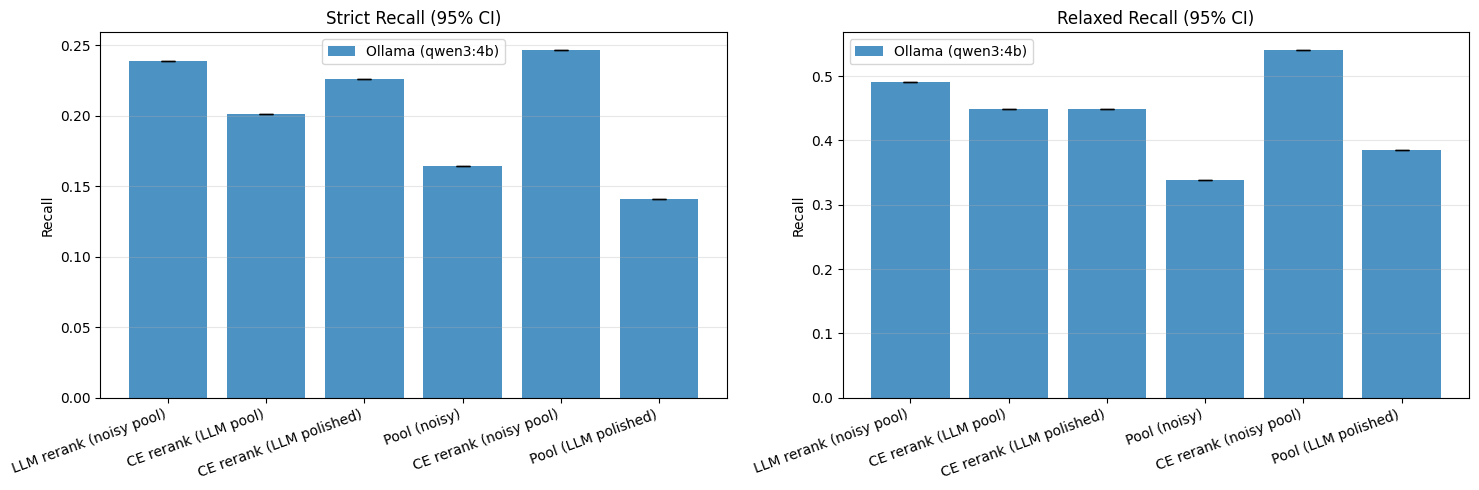

In [ ]:
# Pipeline 7 — Yuan text retrieval + VL reranker (Qwen3-VL-Reranker-2B)
llm_configs = [
    {
        'name':      'Ollama (qwen3:4b)',
        'llm_model': 'qwen3.5:4b',
        'backend':   'ollama',
    },
]
results_pipeline_yuan_vl = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=yuan_client, collection='yuan_passage_collection',
        embed_fn=embedding_model_yuan.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_image=pid_to_image, image_reranker=vl_reranker,
        image_weight=1),
    n_samples=20, pool_k=300, rerank_n=30,
    random_states=[42],
    modes=["llm_simplify", "llm_simplify_retrieve_only", "llm_simplify_retrieve"],
    show_baselines=True,
    plot=False,
    checkpoint_path='./BDATM/jsons/reranking/yuan_vl_checkpoint_7.json'
)

Checkpoint loaded: 4 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.251   0.431
Recall@30 (CE rerank (noisy pool))                        : 0.282   0.545
Recall@30 (LLM rerank (noisy pool))                       : 0.257   0.474
Recall@30 (Pool (LLM polished))                           : 0.247   0.433
Recall@30 (CE rerank (LLM pool))                          : 0.298   0.570
Recall@30 (CE rerank (LLM polished))                      : 0.265   0.508

Results (mean ± 95% CI across 1 seed(s), t df=0):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.257,0.474
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.298,0.570
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.265,0.508
3,Ollama (qwen3:4b),Pool (noisy),0.251,0.431
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.282,0.545
5,Ollama (qwen3:4b),Pool (LLM polished),0.247,0.433


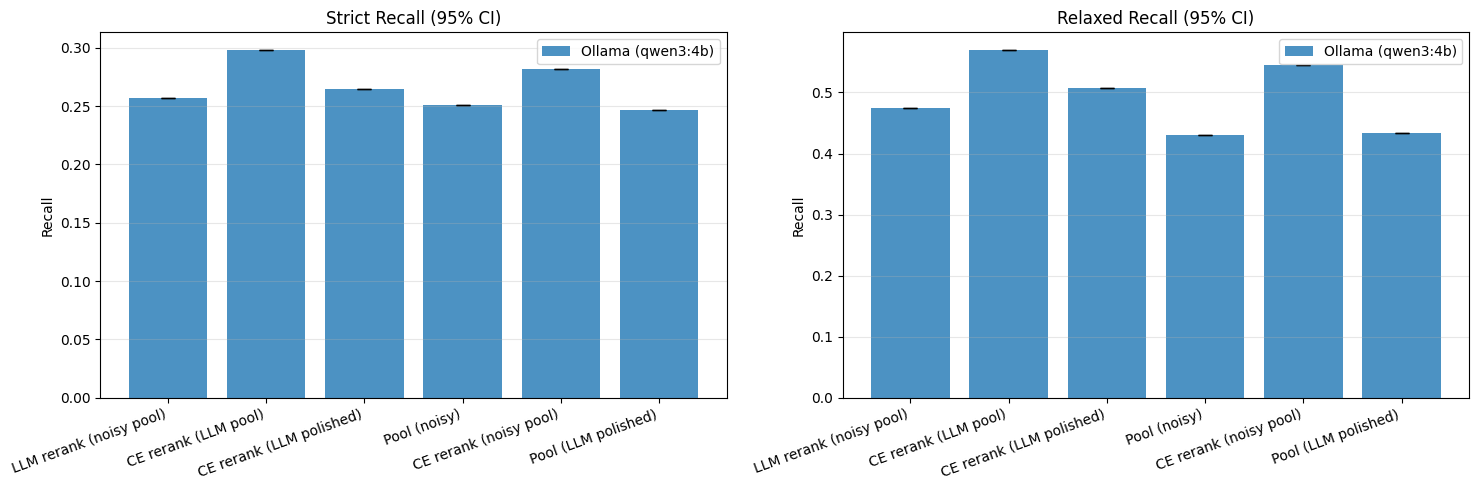

In [ ]:
# Pipeline 8 — Jina text retrieval + VL reranker (Qwen3-VL-Reranker-2B)
results_pipeline_jina_text_vl = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=jina_text_client, collection='jina_passage_collection',
        embed_fn=jina_text_model.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_image=pid_to_image, image_reranker=vl_reranker,
        image_weight=1),
    n_samples=20, pool_k=300, rerank_n=30,
    random_states=[42],
    modes=["llm_simplify", "llm_simplify_retrieve_only", "llm_simplify_retrieve"],
    show_baselines=True,
    plot=False,
    checkpoint_path='./BDATM/jsons/reranking/jina_text_vl_checkpoint_8.json'
)

Checkpoint loaded: 4 entries done

Seed: 42
  [checkpoint] skipping baselines (seed=42)


building cache:   0%|          | 0/20 [00:00<?, ?it/s]

  [checkpoint] skipping llm_simplify (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve_only (Ollama (qwen3:4b), seed=42)
  [checkpoint] skipping llm_simplify_retrieve (Ollama (qwen3:4b), seed=42)

── Ollama (qwen3:4b) ───────────────────────────────────────
                                                    Strict  Relaxed
Recall@30 (Pool (noisy))                                  : 0.280   0.528
Recall@30 (CE rerank (noisy pool))                        : 0.282   0.595
Recall@30 (LLM rerank (noisy pool))                       : 0.244   0.516
Recall@30 (Pool (LLM polished))                           : 0.273   0.485
Recall@30 (CE rerank (LLM pool))                          : 0.265   0.553
Recall@30 (CE rerank (LLM polished))                      : 0.227   0.483

Results (mean ± 95% CI across 1 seed(s), t df=0):


,Config,Mode,Strict Recall,Relaxed Recall
0,Ollama (qwen3:4b),LLM rerank (noisy pool),0.244,0.516
1,Ollama (qwen3:4b),CE rerank (LLM pool),0.265,0.553
2,Ollama (qwen3:4b),CE rerank (LLM polished),0.227,0.483
3,Ollama (qwen3:4b),Pool (noisy),0.280,0.528
4,Ollama (qwen3:4b),CE rerank (noisy pool),0.282,0.595
5,Ollama (qwen3:4b),Pool (LLM polished),0.273,0.485


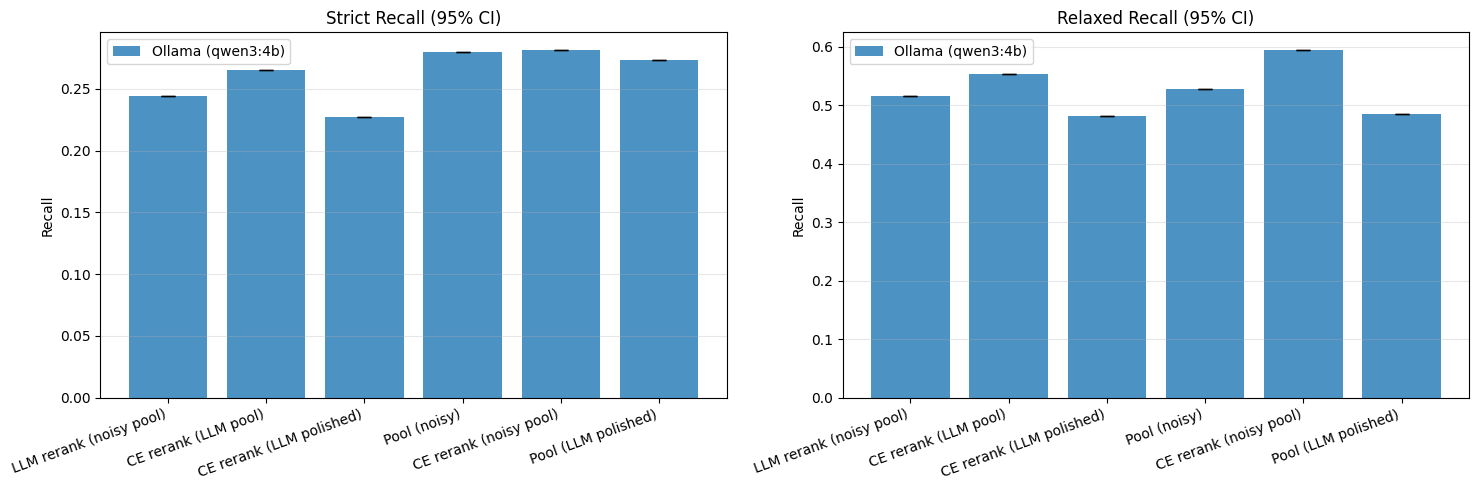

In [ ]:
# Pipeline 9 — Jina image+text retrieval + VL reranker (Qwen3-VL-Reranker-2B)
results_pipeline_jina_image_vl = run_configs(
    configs=llm_configs,
    df=df_noisy_sentences,
    retrieve_fn=lambda s, top_k: retrieve(s, top_k=top_k,
        client=jina_image_client, collection='jina_nano_image_collection',
        embed_fn=jina_image_model.embed_query),
    reranker=lambda q, ids, top_n: rerank_pictograms(q, ids, top_n,
        pid_to_image=pid_to_image, image_reranker=vl_reranker,
        image_weight=1),
    n_samples=20, pool_k=300, rerank_n=30,
    random_states=[42],
    modes=["llm_simplify", "llm_simplify_retrieve_only", "llm_simplify_retrieve"],
    show_baselines=True,
    plot=False,
    checkpoint_path='./BDATM/jsons/reranking/jina_image_vl_checkpoint_9.json'
)


Pipeline comparison (mean ± 95% CI across up to 1 seed(s), t df=0):


,Pipeline,Mode,Strict Recall,Relaxed Recall
0,Yuan + VL reranker,Pool (noisy),0.164,0.338
1,Yuan + VL reranker,CE rerank (noisy pool),0.247,0.541
2,Yuan + VL reranker,LLM rerank (noisy pool),0.238,0.491
3,Yuan + VL reranker,CE rerank (LLM pool),0.201,0.449
4,Yuan + VL reranker,CE rerank (LLM polished),0.226,0.449
5,Yuan + VL reranker,Pool (LLM polished),0.141,0.385
6,Jina text + VL reranker,Pool (noisy),0.251,0.431
7,Jina text + VL reranker,CE rerank (noisy pool),0.282,0.545
8,Jina text + VL reranker,LLM rerank (noisy pool),0.257,0.474
9,Jina text + VL reranker,CE rerank (LLM pool),0.298,0.570


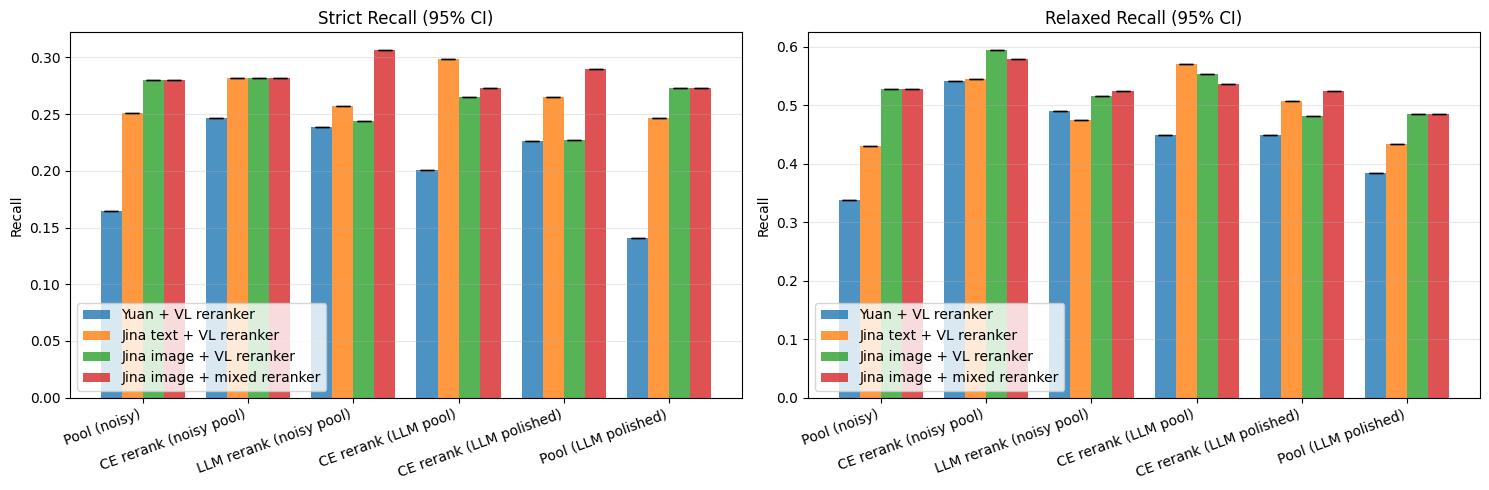

In [54]:
# Compare the 3 VL-reranker pipelines (Pipelines 7-9) side by side, loading
# straight from the saved checkpoints -- no rerun needed.
vl_reranker_checkpoints = {
    'Yuan + VL reranker':       './BDATM/jsons/reranking/yuan_vl_checkpoint_7.json',
    'Jina text + VL reranker':  './BDATM/jsons/reranking/jina_text_vl_checkpoint_8.json',
    'Jina image + VL reranker': './BDATM/jsons/reranking/jina_image_vl_checkpoint_9.json',
    'Jina image + mixed reranker': './BDATM/jsons/reranking/jina_image_mixed_checkpoint_10.json',
}

vl_pipelines_runs_df, vl_pipelines_summary = plot_pipeline_comparison(vl_reranker_checkpoints)

The Vision Language reranker seems to be promising, as it allows to reach a significant improvement in the performances having a higher recall compared to the previously presented results. However, as said before, this is just a small sample with one unique seed and, therefore, further investigations should be done in the future to see if this is a good reranker for this task in order to have more robust results. <br> 

## 6. WebApp application

A small web application has been created to allow the user to input a query and retrieve the corresponding pictograms. Here the Jina-embeddings-v5-omni-nano image+text retrieval with the Qwen3-VL-Reranker-2B vision-language reranker is used, as it gave the most promising results in the previous step. <br>
The user can input a query and the pictograms will be retrieved and reranked. As the numerical results were not totally satisfying due to similarity between pictograms, the user is allowed to choose the pictograms he prefers to then possibly use them in their own personal boards.

In [55]:
os.makedirs("static", exist_ok=True)
shutil.copy("./BDATM/index.html", "static/index.html")

app, port = create_pictogram_server(
    milvus_client      = jina_image_client,
    collection         = "jina_nano_image_collection",
    embed_fn           = jina_image_model.embed_query,
    reranker           = vl_reranker,
    pid_to_description = pid_to_description,
    llm_model          = "qwen3.5:4b",
    static_dir         = "static",
)

[/retrieve] query='symbols for going to school'  simplified='person go school'  pool=400
